# Introduction
This benchmark aims to compare 3 well-know cryptographic libraries: Bouncy Castle, Node's Crypto module and OpenSSL. The cryptographic algorithms I have chosen to test using the given libraries were the following 3 famous algorithms: RSA, SHA-256 and ChaCha20-Poly1305.

The goal of this benchmark isn't to compare the algorithms to each other (for example trying to decide of ChaCha20 or RSA can encrypt a message faster), but rather comparing the libraries to each other and seeing which library can achieve a faster runtime for the chosen algorithms in the given programming language.

# Methodology
For the encryption algorithms (ChaCha20-Poly1305 and RSA) I both measured the encryption and decryption speed of a message.

In the tests I have taken a few notable measures in order to achieve more comparable results. The Java and TypeScript benchmarks were preceded by 20 warmup iterations. However, in the Google Benchmark framework I could find a warmup iteration parameter so I ended up using a fixed 1 second long warmup period. During the benchmarks each algorithm and library pair combination had its speed measured for 10 iterations. The below numbers in the graphs are the statictical mean (average) values of those 10 iterations.

The benchmarks were configured to exclude unncessary overhead, such as setup of the libraries, ensuring the measurements reflected only the execution time of the core cryptographic functions.

## Benchmarking frameworks
For testing the runtime of each algorithm I have used a third-party benchmark library:

- TypeScript: [tinybench](https://github.com/tinylibs/tinybench)
- Java: [Java Microbenchmark Harness](https://github.com/openjdk/jmh)
- C++: [Google BenchMark](https://github.com/google/benchmark)

## Compilers and language versions:

- Typescript: The tests were ran on TypeScript version 6.0.2 using tsx 4.21.0.
- Java: The Java sources were compiled and ran with Oracle OpenJDK 23.0.1.
- C++: The C++ source codes were compiled with Clang 22.1.2 using `-O3` optimization. For building the project I have setup a CMake project and used C++20.


## Hardware
The benchmarks were ran on a M3 Macbook Air.



# Results:

## SHA-256:

SHA-256 is a cryptographic hash function from the SHA-2 family that generates a unique, fixed-size 256-bit signature to ensure data integrity and detect unauthorized modifications.


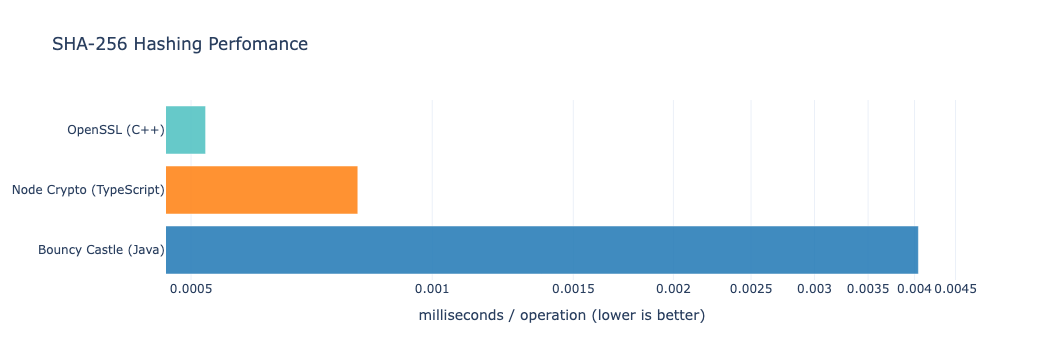

In [13]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

# java: primaryMetric.score is nanoseconds / operation -> we calculate scoreNs / 1e9 (then * 1000 for ms)
java_results = load_json('./bouncycastle-benchmark/results.json')
java_sha = [entry['primaryMetric']['score'] / 1e6 for entry in java_results 
            if 'sha256' in entry['benchmark'].lower()][0]

# node: latency.mean is ms
node_sha_results = load_json('./node-benchmarks/results/sha256-report.json')
node_sha = node_sha_results['tasks'][0]['latency']['mean']

# cpp: real_time is in nanoseconds (we will * 1000 it)
cpp_results = load_json('./openssl-cpp-benchmark/results.json')
cpp_sha = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'sha256' in b['name'].lower()][0]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=['Bouncy Castle (Java)', 'Node Crypto (TypeScript)', 'OpenSSL (C++)'],
    x=[java_sha, node_sha, cpp_sha],
    orientation='h',
    marker_color=['rgba(31, 119, 180, 0.85)', 'rgba(255, 127, 14, 0.85)', 'rgba(75, 192, 192, 0.85)'],
    hovertemplate='<b>%{y}</b><br>Latency: %{x:.6f} ms<extra></extra>'
))

fig.update_layout(
    title='SHA-256 Hashing Perfomance',
    xaxis_type="log",
    template='plotly_white',
    autosize=True,
    xaxis_title='milliseconds / operation (lower is better)',
)

fig.show()

# ChaCha20-Poly1305

ChaCha20-Poly1305 is a symmetric key streaming cypher. It uses the Poly-1305 message authenication algorithm in order to generate a MAC (Message Authenication Code) for the cypher texts so if an eavesdropper were to change the encrypted message, it would be detectable by the source.

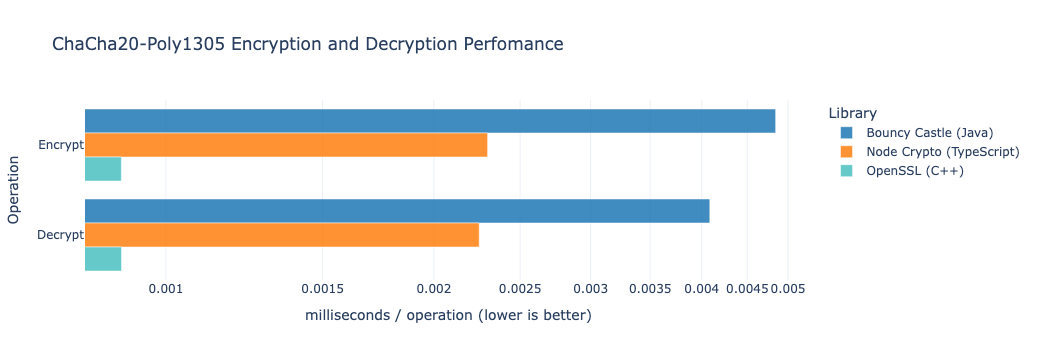

In [14]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

java_results = load_json('./bouncycastle-benchmark/results.json')
node_chacha_results = load_json('./node-benchmarks/results/chacha20-benchmark-results.json')
cpp_results = load_json('./openssl-cpp-benchmark/results.json')

java_enc = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'encrypt' in e['benchmark'].lower()][0]
java_dec = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'decrypt' in e['benchmark'].lower()][0]

node_enc = node_chacha_results['tasks'][0]['latency']['mean']
node_dec = node_chacha_results['tasks'][1]['latency']['mean']

cpp_enc = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
cpp_dec = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

operations = ['Encrypt', 'Decrypt']
colors = {
    'java': 'rgba(31, 119, 180, 0.85)',
    'node': 'rgba(255, 127, 14, 0.85)',
    'cpp': 'rgba(75, 192, 192, 0.85)'
}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=operations,
    x=[java_enc, java_dec],
    name='Bouncy Castle (Java)',
    orientation='h',
    marker_color=colors['java'],
    hovertemplate='<b>Java</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[node_enc, node_dec],
    name='Node Crypto (TypeScript)',
    orientation='h',
    marker_color=colors['node'],
    hovertemplate='<b>Node</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[cpp_enc, cpp_dec],
    name='OpenSSL (C++)',
    orientation='h',
    marker_color=colors['cpp'],
    hovertemplate='<b>C++</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.update_layout(
    title='ChaCha20-Poly1305 Encryption and Decryption Perfomance',
    xaxis_title='milliseconds / operation (lower is better)',
    xaxis_type="log",
    yaxis_title="Operation",
    barmode='group',
    template='plotly_white',
    legend_title="Library",
    autosize=True,
    yaxis=dict(autorange="reversed")
)

fig.show()

# RSA

RSA is an asymmetric cryptographic algorithm that relies on the mathematical difficulty of factoring large prime numbers to provide secure data encryption.


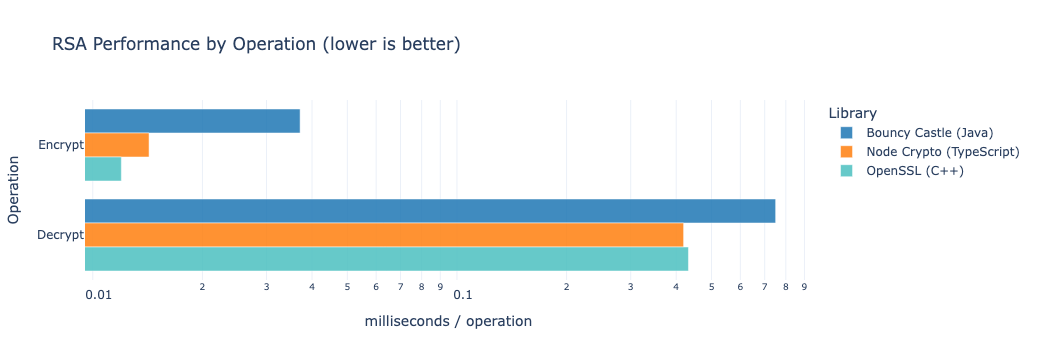

In [3]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

java_results = load_json('./bouncycastle-benchmark/results.json')
node_rsa_results = load_json('./node-benchmarks/results/rsa-benchmark-results.json')
cpp_results = load_json('./openssl-cpp-benchmark/results.json')

java_enc = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'rsa' in e['benchmark'].lower() and 'encrypt' in e['benchmark'].lower()][0]
java_dec = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'rsa' in e['benchmark'].lower() and 'decrypt' in e['benchmark'].lower()][0]

node_enc = node_rsa_results['tasks'][0]['latency']['mean']
node_dec = node_rsa_results['tasks'][1]['latency']['mean']

cpp_enc = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'rsa' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
cpp_dec = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'rsa' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

operations = ['Encrypt', 'Decrypt']
colors = {
    'java': 'rgba(31, 119, 180, 0.85)',
    'node': 'rgba(255, 127, 14, 0.85)',
    'cpp': 'rgba(75, 192, 192, 0.85)'
}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=operations,
    x=[java_enc, java_dec],
    name='Bouncy Castle (Java)',
    orientation='h',
    marker_color=colors['java'],
    hovertemplate='<b>Java</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[node_enc, node_dec],
    name='Node Crypto (TypeScript)',
    orientation='h',
    marker_color=colors['node'],
    hovertemplate='<b>Node</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[cpp_enc, cpp_dec],
    name='OpenSSL (C++)',
    orientation='h',
    marker_color=colors['cpp'],
    hovertemplate='<b>C++</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.update_layout(
    title='RSA Encryption and Decprytion Perfomance',
    xaxis_title='milliseconds / operation (lower is better)',
    xaxis_type="log",
    yaxis_title="Operation",
    barmode='group',
    template='plotly_white',
    legend_title="Library",
    autosize=True,
    yaxis=dict(autorange="reversed")
)

fig.show()

# Conclusion:

In my measurements I have witnessed that OpenSSL managed to outperform or atleast tie each library in every algorithm, as expeceted. However, contirary to my expectation Node's crypto module manage to outperform Java's Bouncy Castle library.

---


# Source code

The source code for all of benchmarks and this webpage can be found in the following Github repository: https://github.com/nagyb3/perfopt-homework

The charts on this website were made with [Chart.js](https://www.chartjs.org/).

# AI dislosure

During the creation of the benchmarks I have used Github Copilot for speeding up the coding process but have manually reviewed every change in order to make results accurate.
